## Setup

In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV

from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, RocCurveDisplay, PrecisionRecallDisplay, precision_score, recall_score, f1_score

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

In [ ]:
RANDOM_STATE = 9
np.random.seed(RANDOM_STATE)

pd.set_option('display.max_colwidth', 1000)
pd.set_option('display.max_columns', 100)
sns.set_theme(style="white", palette='bright')

In [ ]:
# from google.colab import drive
# drive.mount("/content/drive")

# Update if necessary
df = pd.read_csv("../data/stroke-data.csv")
df.head()

Mounted at /content/drive


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


## Preprocessing

In [ ]:
df = df.drop(columns=['id'])
df = df.drop(df[df['gender'] == 'Other'].index)

In [ ]:
df.rename(columns={'Residence_type': 'residence_type'}, inplace=True)

In [ ]:
df['work_type'] = df['work_type'].replace({'children': 'child'})
df.loc[(df['age']<17) & (df['work_type']=='Never_worked'), "work_type"] = 'child'

In [ ]:
df['bmi_missing'] = df['bmi'].isna().astype(int)

In [ ]:
df['gender'] = df['gender'].map({'Male': 0, 'Female': 1})
df['ever_married'] = df['ever_married'].map({'No': 0, 'Yes': 1})

## Modelling

In [ ]:
df.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,residence_type,avg_glucose_level,bmi,smoking_status,stroke,bmi_missing
0,0,67.0,0,1,1,Private,Urban,228.69,36.6,formerly smoked,1,0
1,1,61.0,0,0,1,Self-employed,Rural,202.21,NaN,never smoked,1,1
2,0,80.0,0,1,1,Private,Rural,105.92,32.5,never smoked,1,0
3,1,49.0,0,0,1,Private,Urban,171.23,34.4,smokes,1,0
4,1,79.0,1,0,1,Self-employed,Rural,174.12,24.0,never smoked,1,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5109 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             5109 non-null   int64  
 1   age                5109 non-null   float64
 2   hypertension       5109 non-null   int64  
 3   heart_disease      5109 non-null   int64  
 4   ever_married       5109 non-null   int64  
 5   work_type          5109 non-null   object 
 6   residence_type     5109 non-null   object 
 7   avg_glucose_level  5109 non-null   float64
 8   bmi                4908 non-null   float64
 9   smoking_status     5109 non-null   object 
 10  stroke             5109 non-null   int64  
 11  bmi_missing        5109 non-null   int64  
dtypes: float64(3), int64(6), object(3)
memory usage: 518.9+ KB


In [ ]:
# Feature definitions
num_cols = ['age', 'avg_glucose_level', 'bmi']
bi_cat_cols = ['gender', 'hypertension', 'heart_disease', 'ever_married', 'bmi_missing']
multi_cat_cols = ['work_type', 'residence_type', 'smoking_status']

# Train-test split
X = df.drop(columns=['stroke'])
y = df['stroke']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

# Preprocessing pipelines
num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipe = Pipeline([
    ('encoder', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_pipe, num_cols),
        ('bin', 'passthrough', bi_cat_cols),
        ('cat', cat_pipe, multi_cat_cols)
    ]
)

# Model definitions and hyperparameter grids
models = {
    'logreg': LogisticRegression(max_iter=1000),
    'knn': KNeighborsClassifier(),
    'rf': RandomForestClassifier(random_state=RANDOM_STATE),
    'xgb': XGBClassifier(random_state=RANDOM_STATE)
}

models_param_grid = {
    'logreg': {
        'model__C': [0.01, 0.1, 1, 10, 100],
        'model__class_weight': [{0:1, 1:v} for v in range(1, 10, 2)]
    },
    'knn': {
        'model__n_neighbors': range(2, 11, 2),
        'model__weights': ['uniform', 'distance']
    },
    'rf': {
        'model__max_depth': [10, 20, None],
        'model__n_estimators': [100, 500],
        'model__class_weight': [{0:1, 1:v} for v in range(1, 10, 2)]
    },
    'xgb': {
        'model__n_estimators': [200, 400],
        'model__learning_rate': [0.03, 0.1],
        'model__max_depth': [3, 5],
        'model__subsample': [0.8],
        'model__colsample_bytree': [0.8],
        'model__scale_pos_weight': [1, 10]
    }
}

# Model training & selection
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

results = []
best_score = -1
best_model = None

for name, model in models.items():
    pipeline = Pipeline([
        ('preprocess', preprocessor),
        ('model', model)
    ])

    grid = GridSearchCV(
        estimator=pipeline,
        param_grid=models_param_grid[name],
        scoring={
            'f1': 'f1',
            'precision': 'precision',
            'recall': 'recall',
            'roc_auc': 'roc_auc'
        },
        refit='f1',
        cv=cv,
        n_jobs=-1
    )

    grid.fit(X_train, y_train)

    results.append({
        'model': name,
        'f1': grid.best_score_,
        'precision': grid.cv_results_['mean_test_precision'][grid.best_index_],
        'recall': grid.cv_results_['mean_test_recall'][grid.best_index_],
        'roc_auc': grid.cv_results_['mean_test_roc_auc'][grid.best_index_],
        'params': grid.best_params_
    })

    if grid.best_score_ > best_score:
        best_score = grid.best_score_
        best_model = grid.best_estimator_

# Summarise
results_df = pd.DataFrame(results).sort_values('f1', ascending=False)
print(results_df.round(2))

    model    f1  precision  recall  roc_auc  \
0  logreg  0.30       0.20    0.61     0.85   
3     xgb  0.29       0.21    0.46     0.83   
2      rf  0.15       0.34    0.10     0.83   
1     knn  0.10       0.10    0.10     0.55   

                                                                                                                                                                     params  
0                                                                                                                   {'model__C': 0.01, 'model__class_weight': {0: 1, 1: 9}}  
3  {'model__colsample_bytree': 0.8, 'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 200, 'model__scale_pos_weight': 10, 'model__subsample': 0.8}  
2                                                                                 {'model__class_weight': {0: 1, 1: 9}, 'model__max_depth': 10, 'model__n_estimators': 100}  
1                                                                   

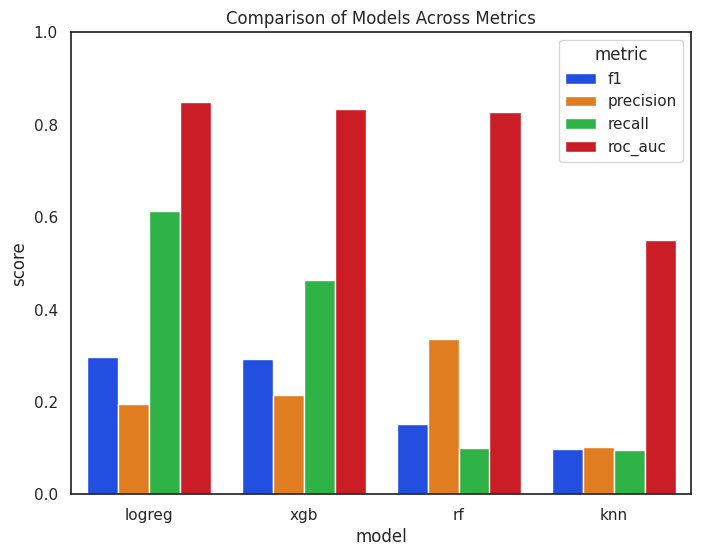

In [ ]:
metrics = ['f1', 'precision', 'recall', 'roc_auc']
results_melted = results_df.melt(id_vars='model', value_vars=metrics, var_name='metric', value_name='score')

plt.figure(figsize=(8,6))
sns.barplot(data=results_melted, x='model', y='score', hue='metric')
plt.ylim(0,1)
plt.title('Comparison of Models Across Metrics')
plt.show()

In [ ]:
# Evaluate best model on test set
y_prob = best_model.predict_proba(X_test)[:,1]

threshold = 0.3
y_pred = (y_prob >= threshold).astype(int)

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

print("\nROC AUC:", roc_auc_score(y_test, y_prob).round(2))


Confusion Matrix
[[681 291]
 [  8  42]]

Classification Report
              precision    recall  f1-score   support

           0       0.99      0.70      0.82       972
           1       0.13      0.84      0.22        50

    accuracy                           0.71      1022
   macro avg       0.56      0.77      0.52      1022
weighted avg       0.95      0.71      0.79      1022


ROC AUC: 0.84


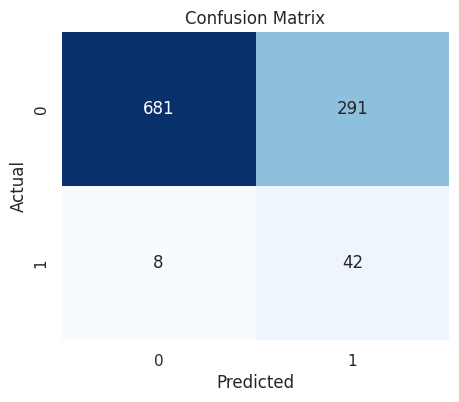

In [ ]:
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cbar=False, cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

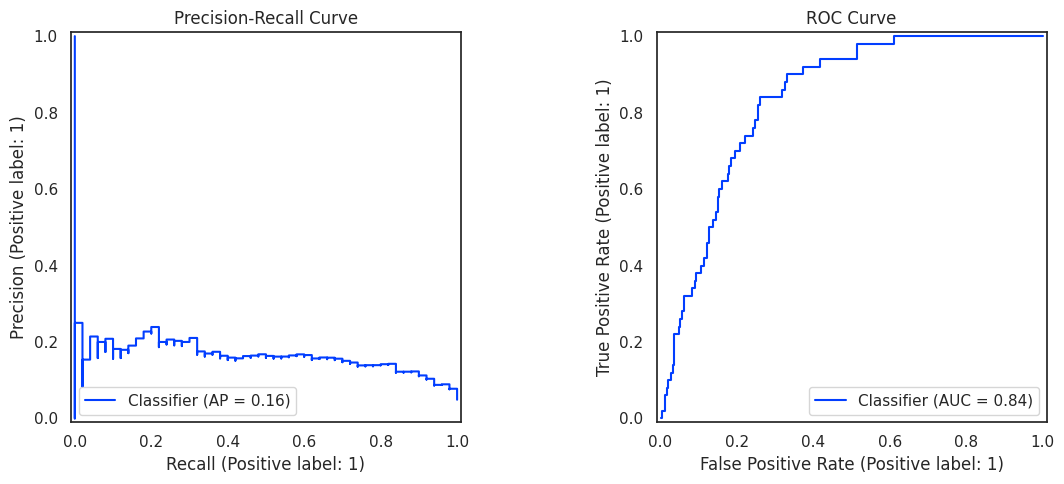

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

PrecisionRecallDisplay.from_predictions(y_test, y_prob, ax=axes[0])
axes[0].set_title('Precision-Recall Curve')

RocCurveDisplay.from_predictions(y_test, y_prob, ax=axes[1])
axes[1].set_title('ROC Curve')

plt.tight_layout()
plt.show()

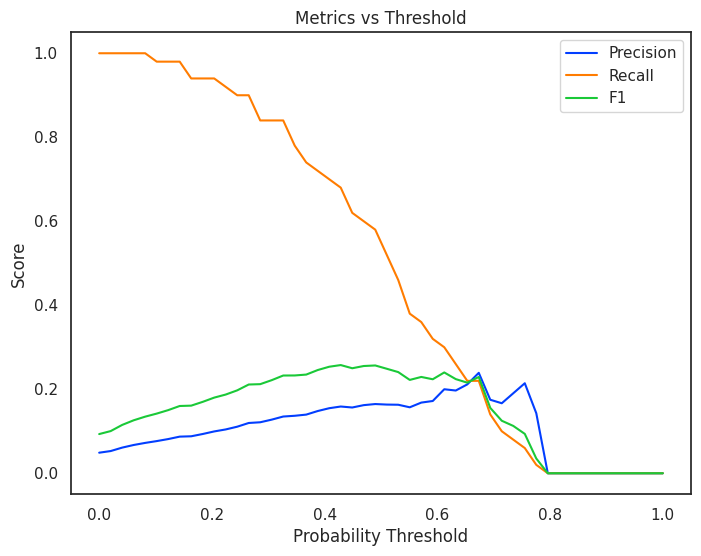

In [ ]:
thresholds = np.linspace(0, 1, 50)
precision_list, recall_list, f1_list = [], [], []

for t in thresholds:
    y_pred_thresh = (y_prob >= t).astype(int)
    precision_list.append(precision_score(y_test, y_pred_thresh, zero_division=0))
    recall_list.append(recall_score(y_test, y_pred_thresh, zero_division=0))
    f1_list.append(f1_score(y_test, y_pred_thresh, zero_division=0))

plt.figure(figsize=(8,6))
plt.plot(thresholds, precision_list, label='Precision')
plt.plot(thresholds, recall_list, label='Recall')
plt.plot(thresholds, f1_list, label='F1')
plt.xlabel('Probability Threshold')
plt.ylabel('Score')
plt.title('Metrics vs Threshold')
plt.legend()
plt.show()

In [ ]:
# Feature importance for Logistic Regression
best_lr_model = best_model.named_steps['model']

cat_features = best_model.named_steps['preprocess'].named_transformers_['cat']['encoder'].get_feature_names_out(multi_cat_cols)
all_features = np.concatenate([num_cols, bi_cat_cols, cat_features])

coef = best_lr_model.coef_[0]

feature_importance = pd.DataFrame({'feature': all_features, 'coef': coef.round(3)})
feature_importance['abs_coef'] = np.abs(feature_importance['coef'])
feature_importance = feature_importance.sort_values(by='abs_coef', ascending=False).reset_index(drop=True)
feature_importance

,feature,coef,abs_coef
0,age,1.307,1.307
1,bmi_missing,0.608,0.608
2,hypertension,0.331,0.331
3,avg_glucose_level,0.206,0.206
4,heart_disease,0.186,0.186
5,smoking_status_never smoked,-0.142,0.142
6,smoking_status_smokes,0.113,0.113
7,smoking_status_formerly smoked,0.110,0.110
8,work_type_child,0.057,0.057
9,work_type_Private,0.048,0.048


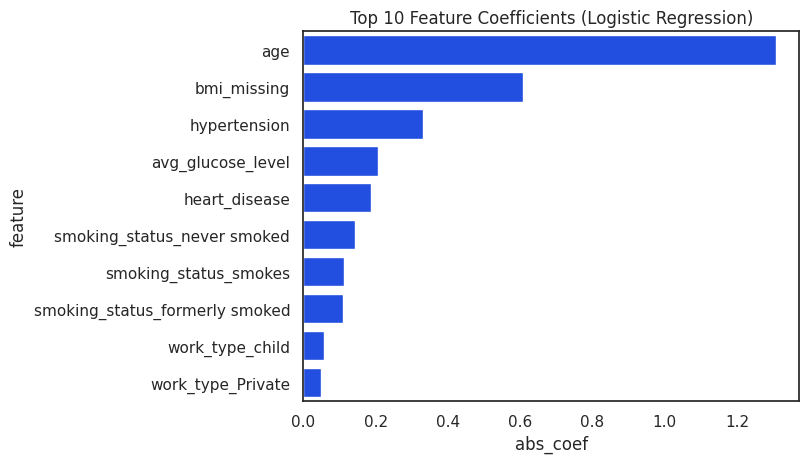

In [ ]:
sns.barplot(feature_importance.head(10), y='feature', x='abs_coef', orient='h')
plt.title('Top 10 Feature Coefficients (Logistic Regression)')
plt.show()